# LaDe-P Demand Forecasting — XGBoost Model

## Goal
Train and evaluate an XGBoost regression model to predict `demand_count` for each `(city, region_id, aoi_id, bucket_hour)` using lag and rolling features.

## Assumptions
- `model_df` is already loaded (from the preprocessing notebook output `lade_hourly_features.csv`).
- All lag/rolling features are pre-computed and NaN rows have been dropped.
- `bucket_hour` is a datetime column.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import warnings
import os
import json
from datetime import datetime
warnings.filterwarnings('ignore')


try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    subprocess.run(["pip", "install", "xgboost", "-q"])
    import xgboost as xgb
    print("XGBoost installed, version:", xgb.__version__)

SEED = 42
np.random.seed(SEED)

# ── GPU Detection (fixed: was returning 'hist' in both branches) ──────────────
try:
    gpu_check = subprocess.run(["nvidia-smi"], capture_output=True)
    TREE_METHOD = "hist"      # Change to "gpu_hist" if you have XGBoost GPU build
    HAS_GPU = gpu_check.returncode == 0
except Exception:
    TREE_METHOD = "hist"
    HAS_GPU = False

print(f"GPU available: {HAS_GPU}  |  tree_method: '{TREE_METHOD}'")
print("Ready.")

XGBoost version: 3.2.0
GPU available: True  |  tree_method: 'hist'
Ready.


In [2]:
# ── Experiment Tracking Setup ─────────────────────────────────────────────────
EXPERIMENTS_PATH = "/content/drive/MyDrive/Senior Project/experiments.csv"

def load_experiments():
    if os.path.exists(EXPERIMENTS_PATH):
        return pd.read_csv(EXPERIMENTS_PATH)
    return pd.DataFrame()

def save_experiment(params, results):
    record = {
        "timestamp":             datetime.now().strftime("%Y-%m-%d %H:%M"),
        "objective":             params.get("objective"),
        "learning_rate":         params.get("learning_rate"),
        "max_depth":             params.get("max_depth"),
        "min_child_weight":      params.get("min_child_weight"),
        "subsample":             params.get("subsample"),
        "colsample_bytree":      params.get("colsample_bytree"),
        "reg_alpha":             params.get("reg_alpha"),
        "reg_lambda":            params.get("reg_lambda"),
        "early_stopping_rounds": params.get("early_stopping_rounds"),
        "best_iteration":        results.get("best_iteration"),
        "val_mae":               results.get("val_mae"),
        "val_poisson":           results.get("val_poisson"),
        "test_mae":              results.get("test_mae"),
        "test_rmse":             results.get("test_rmse"),
        "test_rmsle":            results.get("test_rmsle"),
        "test_poisson":          results.get("test_poisson"),
        "notes":                 params.get("notes", ""),
    }
    df = load_experiments()
    df = pd.concat([df, pd.DataFrame([record])], ignore_index=True)
    df.to_csv(EXPERIMENTS_PATH, index=False)
    print(f"Experiment saved ✅  (total runs: {len(df)})")
    return df

## Step 1 — Load the Preprocessed Dataset

If `model_df` is already in memory (you ran the preprocessing notebook in the same session), skip the CSV read.
Otherwise it reads `lade_hourly_features.csv` from disk.

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
CSV_PATH = "/content/drive/MyDrive/Senior Project/LaDe-Dataset/lade_hourly_features.csv"

if 'model_df' not in globals():
    print("Loading from CSV...")
    model_df = pd.read_csv(CSV_PATH, parse_dates=["bucket_hour"])
    print("Loaded shape:", model_df.shape)
else:
    print("Using existing model_df from memory, shape:", model_df.shape)
    model_df["bucket_hour"] = pd.to_datetime(model_df["bucket_hour"])

model_df.head()

Loading from CSV...
Loaded shape: (16960000, 17)


,city,region_id,aoi_id,aoi_type,bucket_hour,hour,dow,month,is_weekend,demand_count,lag_1,lag_2,lag_24,lag_48,lag_168,roll_24_mean,roll_168_mean
0,Hangzhou,0,749,1,2022-05-08 07:00:00,7,6,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.017857
1,Hangzhou,0,749,1,2022-05-08 08:00:00,8,6,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.017857
2,Hangzhou,0,749,1,2022-05-08 09:00:00,9,6,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.017857
3,Hangzhou,0,749,1,2022-05-08 10:00:00,10,6,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.017857
4,Hangzhou,0,749,1,2022-05-08 11:00:00,11,6,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.017857


In [5]:
for col in ["region_id", "aoi_id", "hour", "dow", "month", "is_weekend",
            "lag_1", "lag_2", "lag_24", "lag_48", "lag_168"]:
    model_df[col] = pd.to_numeric(model_df[col], downcast="integer")

for col in ["roll_24_mean", "roll_168_mean"]:
    model_df[col] = model_df[col].astype("float32")

model_df["demand_count"] = model_df["demand_count"].astype("int16")
print(f"Memory usage: {model_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Memory usage: 1.65 GB


## Step 2 — Chronological Train / Val / Test Split

We split **globally** by time (not per AOI), so:
- **Train**: first 60% of hours
- **Val**: next 20% of hours
- **Test**: last 20% of hours

This prevents any future data from leaking into training.

> Split is done **before** feature engineering so that the calendar
> features added in the next step cannot accidentally encode split membership.

In [6]:
TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20

all_hours = model_df["bucket_hour"].sort_values().unique()
n_hours   = len(all_hours)

train_end = all_hours[int(n_hours * TRAIN_RATIO) - 1]
val_end   = all_hours[int(n_hours * (TRAIN_RATIO + VAL_RATIO)) - 1]

model_df["split"] = np.where(
    model_df["bucket_hour"] <= train_end, "train",
    np.where(model_df["bucket_hour"] <= val_end, "val", "test")
)

split_counts = model_df["split"].value_counts().sort_index()
print(split_counts)
print(f"\nTrain ends:  {train_end}")
print(f"Val ends:    {val_end}")
print(f"Test starts: {model_df.loc[model_df['split'] == 'test', 'bucket_hour'].min()}")

split
test      3392000
train    10176000
val       3392000
Name: count, dtype: int64

Train ends:  2022-08-22 06:00:00
Val ends:    2022-09-26 14:00:00
Test starts: 2022-09-26 15:00:00


## Step 2a — Time and Spatial Features

- **Circadian**: `hour_sin`, `hour_cos` encode the cyclical nature of hours (so hour 23 and hour 0 are close, not far apart).
- **Chinese calendar proxy**: `is_dragon_boat`, `is_mid_autumn` — vectorized using `.between()` and boolean masks.
- **Spatial**: `neighbor_lag_24_mean` = mean of `lag_24` over all other AOIs in the same (city, region) for that hour. ⚠️ Note: this feature is valid for training but needs careful handling at inference time — neighboring AOIs' lag values must be known before predicting.
- **AOI area**: uses coordinate bounding box from `lng/lat` if available; otherwise omitted (constant features add zero information to XGBoost).

In [7]:
# ── Circadian encoding ────────────────────────────────────────────────────────
model_df["hour"]     = model_df["bucket_hour"].dt.hour
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24)

# ── Chinese calendar — vectorized ─────────────────────────────────────────────
# Data covers Jun–Sep 2022 in Jilin, China
dates = model_df["bucket_hour"].dt.normalize()

# Dragon Boat Festival 2022: June 3 (+ 2 days off: Jun 3-5)
model_df["is_dragon_boat"] = dates.between(
    pd.Timestamp("2022-06-03"), pd.Timestamp("2022-06-05")
).astype("int8")

# Mid-Autumn Festival 2022: September 10 (+ 2 days off: Sep 10-12)
model_df["is_mid_autumn"] = dates.between(
    pd.Timestamp("2022-09-10"), pd.Timestamp("2022-09-12")
).astype("int8")

# Combined holiday flag
model_df["is_holiday"] = (
    (model_df["is_dragon_boat"] == 1) | (model_df["is_mid_autumn"] == 1)
).astype("int8")

# ── Spatial: neighbor lag_24 mean ─────────────────────────────────────────────
if "lag_24" in model_df.columns:
    g      = model_df.groupby(["city", "region_id", "bucket_hour"], dropna=False)
    total  = g["lag_24"].transform("sum")
    cnt    = g["lag_24"].transform("count")
    model_df["neighbor_lag_24_mean"] = (
        (total - model_df["lag_24"]) / (cnt - 1).replace(0, np.nan)
    ).fillna(0)
else:
    model_df["neighbor_lag_24_mean"] = 0

# ── AOI area from bounding box (only if raw coordinates are present) ──────────
if "lng" in model_df.columns and "lat" in model_df.columns:
    bbox = model_df.groupby(["city", "region_id", "aoi_id"]).agg(
        lng_min=("lng", "min"), lng_max=("lng", "max"),
        lat_min=("lat", "min"), lat_max=("lat", "max")
    ).reset_index()
    bbox["aoi_area"] = (bbox["lng_max"] - bbox["lng_min"]) * (bbox["lat_max"] - bbox["lat_min"])
    model_df = model_df.merge(bbox[["city", "region_id", "aoi_id", "aoi_area"]],
                              on=["city", "region_id", "aoi_id"], how="left")
    print("aoi_area computed from bounding box.")
else:
    print("lng/lat not available — aoi_area skipped (no placeholder inserted).")

added = [c for c in ["hour_sin", "hour_cos", "is_dragon_boat", "is_mid_autumn",
                      "is_holiday", "neighbor_lag_24_mean", "aoi_area"] if c in model_df.columns]
print("Features added:", added)

lng/lat not available — aoi_area skipped (no placeholder inserted).
Features added: ['hour_sin', 'hour_cos', 'is_dragon_boat', 'is_mid_autumn', 'is_holiday', 'neighbor_lag_24_mean']


## Step 3 — Feature Matrix Construction

- **Drop** `bucket_hour` and `split` (not model inputs) and `demand_count` (the target).
- **One-hot encode** low-cardinality categoricals: `city`, `aoi_type`.
- `region_id` and `aoi_id` are kept as numeric IDs (high cardinality — OHE would explode the feature space).

In [8]:
from sklearn.preprocessing import TargetEncoder

TARGET    = "demand_count"
DROP_COLS = ["bucket_hour", "split", TARGET]
OHE_COLS  = ["city", "aoi_type"]

# Target-encode aoi_id using train rows only — no leakage
train_mask = model_df["split"] == "train"
te = TargetEncoder(target_type="continuous", random_state=SEED)
model_df["aoi_id_encoded"] = te.fit_transform(
    model_df[["aoi_id"]].astype("int64"),
    model_df[TARGET].astype("float64")
)
# Note: fit_transform on full df is fine here because TargetEncoder  uses cross-fitting internally to prevent leakage

encoded = pd.get_dummies(
    model_df.drop(columns=DROP_COLS),
    columns=OHE_COLS,
    drop_first=True
)

FEATURE_COLS = encoded.columns.tolist()
print(f"Number of features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Number of features: 35
['region_id', 'aoi_id', 'hour', 'dow', 'month', 'is_weekend', 'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168', 'roll_24_mean', 'roll_168_mean', 'hour_sin', 'hour_cos', 'is_dragon_boat', 'is_mid_autumn', 'is_holiday', 'neighbor_lag_24_mean', 'aoi_id_encoded', 'aoi_type_1', 'aoi_type_2', 'aoi_type_3', 'aoi_type_4', 'aoi_type_5', 'aoi_type_6', 'aoi_type_7', 'aoi_type_8', 'aoi_type_9', 'aoi_type_10', 'aoi_type_11', 'aoi_type_12', 'aoi_type_13', 'aoi_type_14', 'aoi_type_15']


## Step 4 — Prepare Train / Val / Test Arrays

- **Train**: sample up to 2M rows if needed (RAM management).
- **sample_weight**: weighted by total demand volume per AOI — busier zones get higher weight. This is more meaningful than weighting by observation count (which was identical across all AOIs in the balanced grid).

In [9]:
MAX_TRAIN_ROWS = 2_000_000

split_mask = model_df["split"]

train_idx = model_df.index[split_mask == "train"]
val_idx   = model_df.index[split_mask == "val"]
test_idx  = model_df.index[split_mask == "test"]

if len(train_idx) > MAX_TRAIN_ROWS:
    rng = np.random.RandomState(SEED)
    train_idx = train_idx[rng.choice(len(train_idx), MAX_TRAIN_ROWS, replace=False)]
    print(f"Train sampled to {MAX_TRAIN_ROWS:,} rows")
else:
    print(f"Train rows: {len(train_idx):,}")

X_train = encoded.loc[train_idx]
y_train = model_df.loc[train_idx, TARGET]

X_val  = encoded.loc[val_idx]
y_val  = model_df.loc[val_idx, TARGET]

X_test  = encoded.loc[test_idx]
y_test  = model_df.loc[test_idx, TARGET]

# ── Sample weights: by total demand volume per AOI ────────────────────────────
# Weighting by observation count was broken (all weights = 1.0 on a balanced grid).
# Weighting by demand volume gives higher weight to genuinely busy zones.
aoi_demand = (
    model_df.loc[train_idx]
    .groupby(["city", "region_id", "aoi_id"])[TARGET]
    .sum()
    .reset_index()
    .rename(columns={TARGET: "aoi_total_demand"})
)
train_meta    = model_df.loc[train_idx, ["city", "region_id", "aoi_id"]].copy()
train_meta    = train_meta.merge(aoi_demand, on=["city", "region_id", "aoi_id"], how="left")
sample_weight = train_meta["aoi_total_demand"].fillna(1).values.astype(np.float64)
sample_weight = sample_weight / sample_weight.mean()  # normalize: mean weight = 1

print(f"Val rows:  {len(X_val):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Sample weight range: [{sample_weight.min():.3f}, {sample_weight.max():.3f}]")

Train sampled to 2,000,000 rows
Val rows:  3,392,000
Test rows: 3,392,000
Sample weight range: [0.000, 23.479]


In [10]:
# Cell 12 ends with:
# X_train, X_val, X_test, y_train, y_val, y_test are defined here

# ADD THIS immediately after:
X_train = X_train.astype("float32")
X_val   = X_val.astype("float32")
X_test  = X_test.astype("float32")
print(f"X_train RAM: {X_train.memory_usage(deep=True).sum() / 1e9:.2f} GB")

X_train RAM: 0.30 GB


In [11]:
# Continuing in the same cell after Fix 3:
del model_df, encoded
import gc; gc.collect()
print("Freed model_df and encoded ✅")

Freed model_df and encoded ✅


## Step 5 — Baseline Models

Two simple baselines to benchmark against:
- **Baseline A** (`lag_24`): predict using the value from exactly 24 hours ago.
- **Baseline B** (`roll_24_mean`): predict using the 24-hour rolling average.

In [12]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def rmsle(y_true, y_pred):
    return np.sqrt(np.mean(
        (np.log1p(y_true) - np.log1p(np.clip(y_pred, 0, None)))**2
    ))

def poisson_deviance(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-8, None)  # avoid log(0)
    return 2 * np.mean(
        np.where(y_true == 0,
                 y_pred,
                 y_true * np.log(y_true / y_pred) + (y_pred - y_true))
    )

def rounded_accuracy(y_true, y_pred):
    y_true = np.rint(np.asarray(y_true)).astype(int)
    y_pred = np.rint(np.clip(np.asarray(y_pred), 0, None)).astype(int)
    return np.mean(y_true == y_pred)

def evaluate(y_true, y_pred, name, split_name):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return {
        "Model":            name,
        "Split":            split_name,
        "Accuracy":         rounded_accuracy(y_true, y_pred),
        "MAE":              mae(y_true, y_pred),
        "RMSE":             rmse(y_true, y_pred),
        "RMSLE":            rmsle(y_true, y_pred),
        "Poisson Deviance": poisson_deviance(y_true, y_pred),
    }

results = []

for split_name, X_s, y_s in [("val", X_val, y_val), ("test", X_test, y_test)]:
    results.append(evaluate(y_s, X_s["lag_24"],       "Baseline lag_24",       split_name))
    results.append(evaluate(y_s, X_s["roll_24_mean"], "Baseline roll_24_mean", split_name))

print(pd.DataFrame(results).to_string(index=False))

                Model Split  Accuracy      MAE     RMSE    RMSLE  Poisson Deviance
      Baseline lag_24   val  0.935685 0.124652 0.711538 0.244770          1.955190
Baseline roll_24_mean   val  0.923265 0.193086 0.731247 0.259359          0.968565
      Baseline lag_24  test  0.934140 0.138161 0.793542 0.257157          2.150413
Baseline roll_24_mean  test  0.912950 0.216410 0.812631 0.276663          1.031940


In [13]:
assert (y_train >= 0).all(), "Negative values in y_train — count:poisson will fail"
assert (y_val   >= 0).all(), "Negative values in y_val"

## Step 6 — Train XGBoost (Main Model) with Early Stopping

In [14]:
model_poisson = xgb.XGBRegressor(
    objective             = "count:poisson",
    tree_method           = TREE_METHOD,
    n_estimators          = 2500, # before 5000
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 10, # next 15
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 2.0, # next 3.0
    random_state          = SEED,
    n_jobs                = -1,
    eval_metric           = ["mae", "poisson-nloglik"],
    early_stopping_rounds = 50, # before 100
)

model_poisson.fit(
    X_train, y_train,
    sample_weight = sample_weight,
    eval_set      = [(X_train, y_train), (X_val, y_val)],
    verbose       = 50,
)
print(f"Poisson best iteration: {model_poisson.best_iteration}")

[0]	validation_0-mae:0.38884	validation_0-poisson-nloglik:0.48118	validation_1-mae:0.40666	validation_1-poisson-nloglik:0.52723
[50]	validation_0-mae:0.20465	validation_0-poisson-nloglik:0.26426	validation_1-mae:0.22471	validation_1-poisson-nloglik:0.29490
[100]	validation_0-mae:0.14458	validation_0-poisson-nloglik:0.20209	validation_1-mae:0.16377	validation_1-poisson-nloglik:0.22836
[150]	validation_0-mae:0.12265	validation_0-poisson-nloglik:0.18308	validation_1-mae:0.14150	validation_1-poisson-nloglik:0.20921
[200]	validation_0-mae:0.11430	validation_0-poisson-nloglik:0.17647	validation_1-mae:0.13294	validation_1-poisson-nloglik:0.20276
[250]	validation_0-mae:0.11140	validation_0-poisson-nloglik:0.17390	validation_1-mae:0.12969	validation_1-poisson-nloglik:0.20044
[300]	validation_0-mae:0.10977	validation_0-poisson-nloglik:0.17239	validation_1-mae:0.12804	validation_1-poisson-nloglik:0.19929
[350]	validation_0-mae:0.10903	validation_0-poisson-nloglik:0.17139	validation_1-mae:0.12744	

In [15]:
# Secondary Model
model_log = xgb.XGBRegressor(
    objective             = "reg:squaredlogerror",
    tree_method           = TREE_METHOD,
    n_estimators          = 5000,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 10,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 2.0,
    random_state          = SEED,
    n_jobs                = -1,
    eval_metric           = ["mae", "rmsle"],
    early_stopping_rounds = 100,
)

model_log.fit(
    X_train, y_train,
    sample_weight = sample_weight,
    eval_set      = [(X_train, y_train), (X_val, y_val)],
    verbose       = 50,
)
print(f"squaredlogerror best iteration: {model_log.best_iteration}")

[0]	validation_0-mae:0.17582	validation_0-rmsle:0.22135	validation_1-mae:0.19641	validation_1-rmsle:0.24474
[50]	validation_0-mae:0.11040	validation_0-rmsle:0.17762	validation_1-mae:0.12979	validation_1-rmsle:0.19261
[100]	validation_0-mae:0.10219	validation_0-rmsle:0.17363	validation_1-mae:0.12051	validation_1-rmsle:0.18767
[150]	validation_0-mae:0.10030	validation_0-rmsle:0.17239	validation_1-mae:0.11828	validation_1-rmsle:0.18660
[200]	validation_0-mae:0.09903	validation_0-rmsle:0.17171	validation_1-mae:0.11702	validation_1-rmsle:0.18621
[250]	validation_0-mae:0.09805	validation_0-rmsle:0.17107	validation_1-mae:0.11603	validation_1-rmsle:nan
[300]	validation_0-mae:0.09724	validation_0-rmsle:0.17050	validation_1-mae:0.11537	validation_1-rmsle:nan
[314]	validation_0-mae:0.09710	validation_0-rmsle:0.17035	validation_1-mae:0.11526	validation_1-rmsle:nan
squaredlogerror best iteration: 214


In [16]:
pred_val = model_log.predict(X_val)
print(pred_val.min(), pred_val.max())
print((y_val < 0).sum())

-0.96094733 17.20897
0


## Step 7 — Training Curves

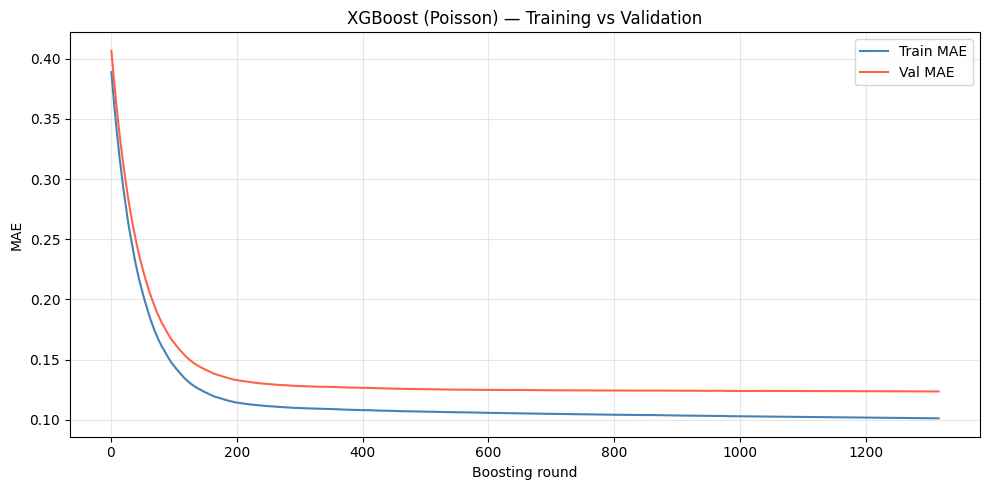

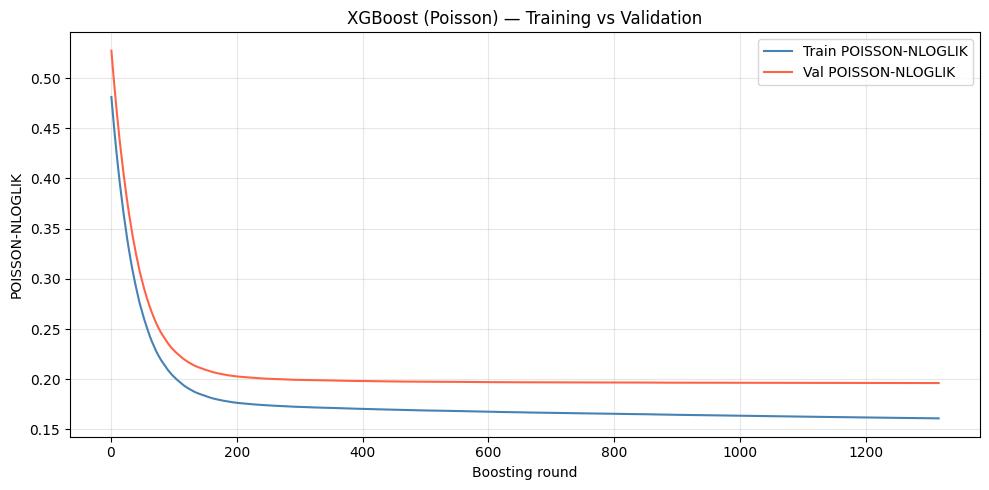

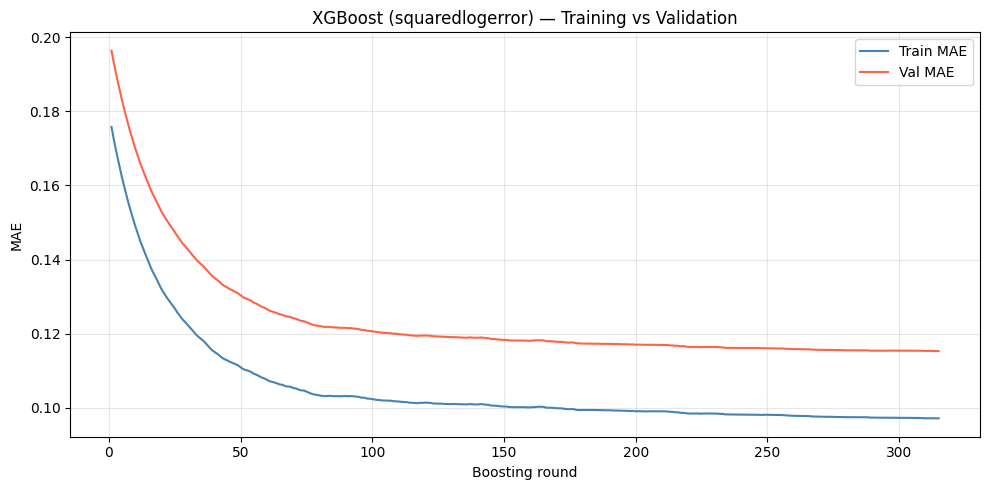

In [17]:
def plot_train_val_curves(evals_result, title="Model", metric="mae"):
    fig, ax = plt.subplots(figsize=(10, 5))

    if "validation_0" in evals_result:
        train_metric = evals_result["validation_0"][metric]
        ax.plot(range(1, len(train_metric) + 1), train_metric,
                label=f"Train {metric.upper()}", color="steelblue", linewidth=1.5)

    if "validation_1" in evals_result:
        val_metric = evals_result["validation_1"][metric]
        ax.plot(range(1, len(val_metric) + 1), val_metric,
                label=f"Val {metric.upper()}", color="tomato", linewidth=1.5)

    ax.set_xlabel("Boosting round")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{title} — Training vs Validation")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Poisson — has both mae and poisson-nloglik
plot_train_val_curves(model_poisson.evals_result(), title="XGBoost (Poisson)", metric="mae")
plot_train_val_curves(model_poisson.evals_result(), title="XGBoost (Poisson)", metric="poisson-nloglik")

# squaredlogerror — has mae only
plot_train_val_curves(model_log.evals_result(), title="XGBoost (squaredlogerror)", metric="mae")

## Step 8 — Evaluate All Models: Final Comparison Table

In [18]:
def predict_clipped(m, X):
    return np.clip(m.predict(X), 0, None)

results = []

# Poisson
val_preds_poisson  = predict_clipped(model_poisson, X_val)
test_preds_poisson = predict_clipped(model_poisson, X_test)
results.append(evaluate(y_val,  val_preds_poisson,  "XGBoost (Poisson)", "val"))
results.append(evaluate(y_test, test_preds_poisson, "XGBoost (Poisson)", "test"))

# squaredlogerror
val_preds_log  = predict_clipped(model_log, X_val)
test_preds_log = predict_clipped(model_log, X_test)
results.append(evaluate(y_val,  val_preds_log,  "XGBoost (squaredlogerror)", "val"))
results.append(evaluate(y_test, test_preds_log, "XGBoost (squaredlogerror)", "test"))

# Comparison table
results_df = pd.DataFrame(results)
comparison = results_df.pivot(index="Model", columns="Split",
                              values=["Accuracy", "MAE", "RMSE", "RMSLE", "Poisson Deviance"])
comparison.columns = [f"{metric}_{split}" for metric, split in comparison.columns]
comparison = comparison[[
    "Accuracy_val",         "Accuracy_test",
    "MAE_val",              "MAE_test",
    "RMSE_val",             "RMSE_test",
    "RMSLE_val",            "RMSLE_test",
    "Poisson Deviance_val", "Poisson Deviance_test",
]]

print("\n=== Model Comparison ===")
print(comparison.to_string())


=== Model Comparison ===
                           Accuracy_val  Accuracy_test   MAE_val  MAE_test  RMSE_val  RMSE_test  RMSLE_val  RMSLE_test  Poisson Deviance_val  Poisson Deviance_test
Model                                                                                                                                                              
XGBoost (Poisson)              0.943295       0.939792  0.123656  0.137520  0.541784   0.621075   0.190139     0.20234              0.280371               0.314700
XGBoost (squaredlogerror)      0.949449       0.946662  0.115194  0.128133  0.577833   0.656311   0.186021     0.19776              0.325081               0.369822


In [19]:
# ── Log Experiment ────────────────────────────────────────────────────────────
mp = model_poisson.get_params()
PARAMS = {
    "objective":              mp["objective"],
    "learning_rate":          mp["learning_rate"],
    "max_depth":              mp["max_depth"],
    "min_child_weight":       mp["min_child_weight"],
    "subsample":              mp["subsample"],
    "colsample_bytree":       mp["colsample_bytree"],
    "reg_alpha":              mp["reg_alpha"],
    "reg_lambda":             mp["reg_lambda"],
    "early_stopping_rounds":  mp["early_stopping_rounds"],
    "notes":                  "run 1 — baseline poisson, 2214 AOIs, target encoding aoi_id",
}

evals   = model_poisson.evals_result()
best_it = model_poisson.best_iteration

row = comparison.loc["XGBoost (Poisson)"]  # pull directly from pivoted table

RESULTS = {
    "best_iteration": best_it,
    "val_mae":        round(evals["validation_1"]["mae"][best_it], 6),
    "val_poisson":    round(evals["validation_1"]["poisson-nloglik"][best_it], 6),
    "test_accuracy":  round(float(row["Accuracy_test"]),         6),
    "test_mae":       round(float(row["MAE_test"]),              6),
    "test_rmse":      round(float(row["RMSE_test"]),             6),
    "test_rmsle":     round(float(row["RMSLE_test"]),            6),
    "test_poisson":   round(float(row["Poisson Deviance_test"]), 6),
}

save_experiment(PARAMS, RESULTS)

Experiment saved ✅  (total runs: 4)


,timestamp,objective,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,early_stopping_rounds,best_iteration,val_mae,val_poisson,test_mae,test_rmse,test_rmsle,test_poisson,notes
0,2026-04-04 20:55,count:poisson,0.05,6,10,0.8,0.8,0.1,2.0,50,1192,0.123643,0.196221,0.137504,0.620930,0.202354,0.314702,"run 1 — baseline poisson, 2214 AOIs, target en..."
1,2026-04-18 16:44,count:poisson,0.05,6,10,0.8,0.8,0.1,2.0,50,1264,0.123656,0.196145,0.137520,0.621075,0.202340,0.314700,"run 1 — baseline poisson, 2214 AOIs, target en..."
2,2026-04-18 17:08,count:poisson,0.05,6,10,0.8,0.8,0.1,2.0,50,1264,0.123656,0.196145,0.137520,0.621075,0.202340,0.314700,"run 1 — baseline poisson, 2214 AOIs, target en..."
3,2026-04-18 18:50,count:poisson,0.05,6,10,0.8,0.8,0.1,2.0,50,1264,0.123656,0.196145,0.137520,0.621075,0.202340,0.314700,"run 1 — baseline poisson, 2214 AOIs, target en..."


## Step 9 — Feature Importance

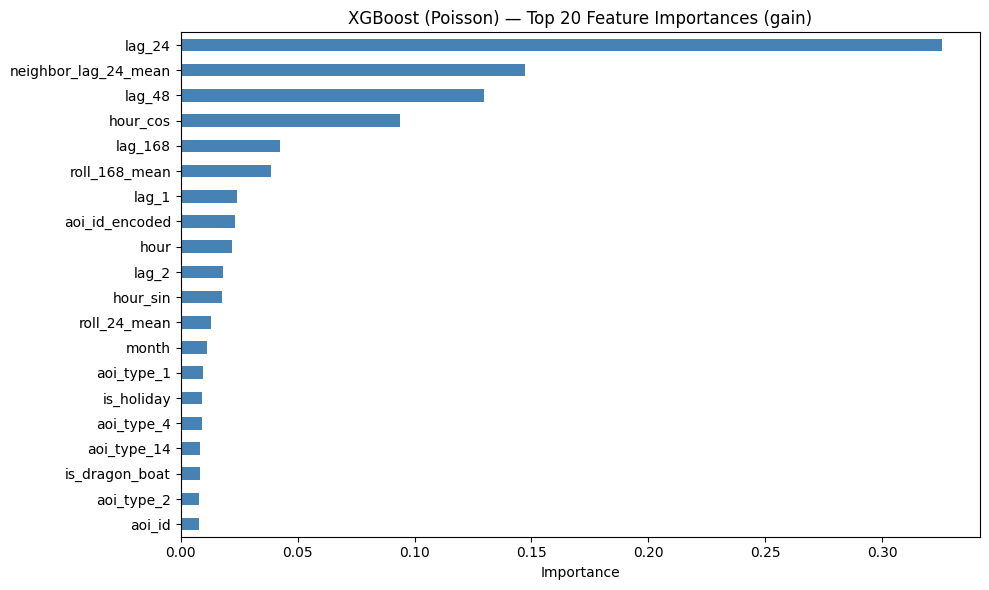

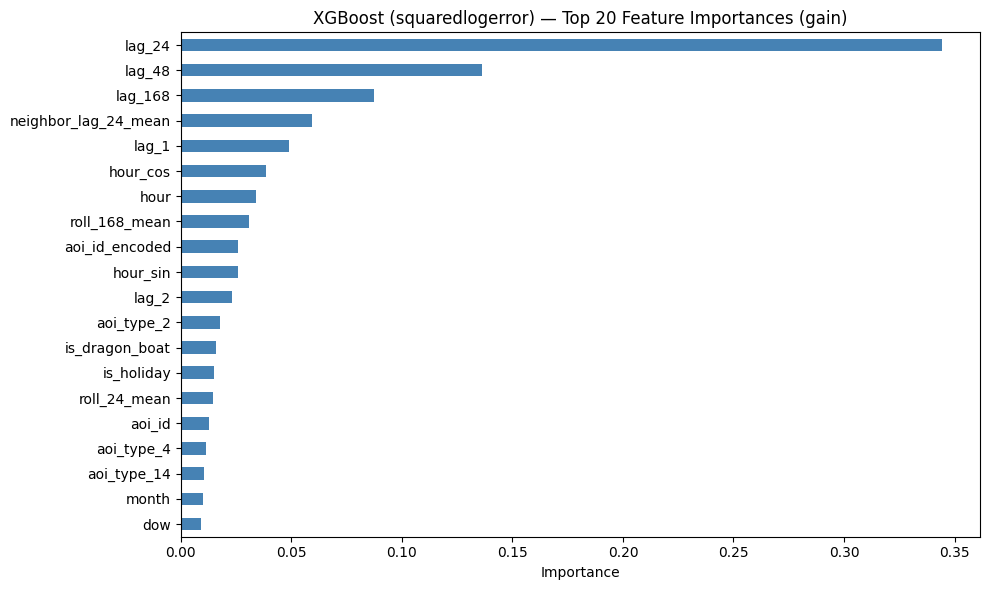

In [20]:
for name, mdl in [("Poisson", model_poisson), ("squaredlogerror", model_log)]:
    importance = (
        pd.Series(mdl.feature_importances_, index=FEATURE_COLS)
        .sort_values(ascending=False)
        .head(20)
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    importance.plot(kind="barh", ax=ax, color="steelblue")
    ax.invert_yaxis()
    ax.set_title(f"XGBoost ({name}) — Top 20 Feature Importances (gain)")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

## Step 10 — Example AOI Plot: Actual vs Predicted

Pick the busiest AOI in the test set and plot actual demand vs XGBoost prediction vs lag_24 baseline.

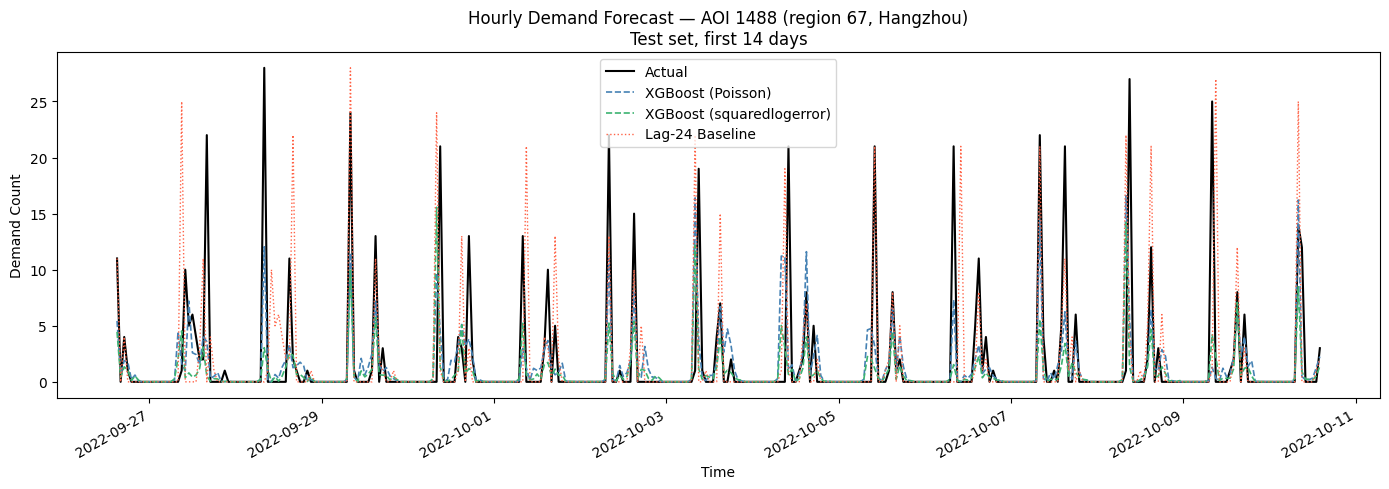

Selected AOI: city=Hangzhou, region_id=67, aoi_id=1488
Test rows for this AOI: 848
Freed model_df ✅


In [21]:
# Session crashes everytime i run this block

# ── Step 10 — Example AOI Plot: Actual vs Predicted ──────────────────────────
model_df = pd.read_csv(CSV_PATH, parse_dates=["bucket_hour"])

# Re-create test_idx using val_end cutoff
test_idx  = model_df.index[model_df["bucket_hour"] > val_end]
test_slice = model_df.loc[test_idx].copy()
test_slice["pred_poisson"] = test_preds_poisson
test_slice["pred_log"]     = test_preds_log
test_slice["pred_lag24"]   = X_test["lag_24"].values

# Busiest AOI by total demand in test
best_aoi = (
    test_slice.groupby(["city", "region_id", "aoi_id"])["demand_count"]
    .sum().idxmax()
)
city_s, region_s, aoi_s = best_aoi

aoi_test = (
    test_slice[
        (test_slice["city"]      == city_s) &
        (test_slice["region_id"] == region_s) &
        (test_slice["aoi_id"]    == aoi_s)
    ]
    .sort_values("bucket_hour")
)

PLOT_DAYS     = 14
aoi_test_plot = aoi_test.head(24 * PLOT_DAYS)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aoi_test_plot["bucket_hour"], aoi_test_plot["demand_count"],
        label="Actual",                    color="black",         linewidth=1.5)
ax.plot(aoi_test_plot["bucket_hour"], aoi_test_plot["pred_poisson"],
        label="XGBoost (Poisson)",         color="steelblue",     linewidth=1.2, linestyle="--")
ax.plot(aoi_test_plot["bucket_hour"], aoi_test_plot["pred_log"],
        label="XGBoost (squaredlogerror)", color="mediumseagreen",linewidth=1.2, linestyle="--")
ax.plot(aoi_test_plot["bucket_hour"], aoi_test_plot["pred_lag24"],
        label="Lag-24 Baseline",           color="tomato",        linewidth=1.0, linestyle=":")

ax.set_title(
    f"Hourly Demand Forecast — AOI {aoi_s} (region {region_s}, {city_s})\n"
    f"Test set, first {PLOT_DAYS} days"
)
ax.set_xlabel("Time")
ax.set_ylabel("Demand Count")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Selected AOI: city={city_s}, region_id={region_s}, aoi_id={aoi_s}")
print(f"Test rows for this AOI: {len(aoi_test)}")

# Free memory again after plotting
del model_df
import gc; gc.collect()
print("Freed model_df ✅")

In [22]:
MODEL_DIR = "/content/drive/MyDrive/Senior Project/models/"
import os
os.makedirs(MODEL_DIR, exist_ok=True)

model_poisson.save_model(MODEL_DIR + "xgb_poisson.json")
model_log.save_model(MODEL_DIR + "xgb_squaredlogerror.json")

print("Models saved to Google Drive:")
print(f"  {MODEL_DIR}xgb_poisson.json")
print(f"  {MODEL_DIR}xgb_squaredlogerror.json")

Models saved to Google Drive:
  /content/drive/MyDrive/Senior Project/models/xgb_poisson.json
  /content/drive/MyDrive/Senior Project/models/xgb_squaredlogerror.json


In [23]:
# ── Compare All Experiments ───────────────────────────────────────────────────
df_exp = load_experiments()
comparison_exp = df_exp.sort_values("test_mae").reset_index(drop=True)
comparison_exp.index += 1

display(comparison_exp[[
    "timestamp", "notes",
    "min_child_weight", "reg_lambda", "learning_rate",
    "best_iteration",
    "val_mae", "test_mae",
    "val_poisson", "test_poisson",
    "test_rmsle"
]])

best = comparison_exp.iloc[0]
print(f"\nBest run so far:")
print(f"  Timestamp     : {best['timestamp']}")
print(f"  Notes         : {best['notes']}")
print(f"  Test MAE      : {best['test_mae']}")
print(f"  Test Poisson  : {best['test_poisson']}")
print(f"  Best iteration: {best['best_iteration']}")

,timestamp,notes,min_child_weight,reg_lambda,learning_rate,best_iteration,val_mae,test_mae,val_poisson,test_poisson,test_rmsle
1,2026-04-04 20:55,"run 1 — baseline poisson, 2214 AOIs, target en...",10,2.0,0.05,1192,0.123643,0.137504,0.196221,0.314702,0.202354
2,2026-04-18 16:44,"run 1 — baseline poisson, 2214 AOIs, target en...",10,2.0,0.05,1264,0.123656,0.137520,0.196145,0.314700,0.202340
3,2026-04-18 17:08,"run 1 — baseline poisson, 2214 AOIs, target en...",10,2.0,0.05,1264,0.123656,0.137520,0.196145,0.314700,0.202340
4,2026-04-18 18:50,"run 1 — baseline poisson, 2214 AOIs, target en...",10,2.0,0.05,1264,0.123656,0.137520,0.196145,0.314700,0.202340



Best run so far:
  Timestamp     : 2026-04-04 20:55
  Notes         : run 1 — baseline poisson, 2214 AOIs, target encoding aoi_id
  Test MAE      : 0.137504
  Test Poisson  : 0.314702
  Best iteration: 1192
